In [ ]:
# Install required packages
!pip -q install kagglehub pandas numpy

import os
import glob
import pandas as pd
import numpy as np
import kagglehub

print("=" * 70)
print("FLIGHT DATA 2024 - AUTOMATIC CLEANING")
print("=" * 70)

# 1. AUTOMATICALLY DOWNLOAD DATASET FROM KAGGLE


print("\n[1] Downloading dataset from Kaggle...")
print("Please wait - the dataset is large.")

dataset_path = kagglehub.dataset_download(
    "hrishitpatil/flight-data-2024"
)

print("\nDataset downloaded automatically!")
print("Dataset location:")
print(dataset_path)


# 2. FIND THE CSV AUTOMATICALLY


print("\n[2] Searching for CSV file...")

csv_files = glob.glob(
    os.path.join(dataset_path, "**", "*.csv"),
    recursive=True
)

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file was found inside the Kaggle dataset."
    )

print("\nCSV files found:")

for file in csv_files:
    print(" -", os.path.basename(file))


# 3. SELECT THE MAIN FLIGHT CSV


flight_csv = None

for file in csv_files:

    name = os.path.basename(file).lower()

    if (
        "flight_data_2024.csv" in name
        and "sample" not in name
    ):
        flight_csv = file
        break


# If exact name is different, select largest CSV
if flight_csv is None:

    flight_csv = max(
        csv_files,
        key=os.path.getsize
    )


print("\nMain dataset selected:")
print(flight_csv)



# 4. READ HEADER ONLY


print("\n[3] Reading dataset structure...")

header = pd.read_csv(
    flight_csv,
    nrows=0
)

original_columns = list(header.columns)

print("\nOriginal number of columns:")
print(len(original_columns))

print("\nColumns:")
for i, col in enumerate(original_columns, 1):
    print(i, ":", col)



# 5. COUNT ORIGINAL ROWS


print("\n[4] Counting original rows...")

original_rows = 0

for chunk in pd.read_csv(
    flight_csv,
    usecols=[original_columns[0]],
    chunksize=500000
):
    original_rows += len(chunk)

print(
    f"Original rows: {original_rows:,}"
)

# 6. OUTPUT FILE


output_file = "/content/flight_data_2024_cleaned.csv"

# Delete previous cleaned file
if os.path.exists(output_file):
    os.remove(output_file)


# 7. CLEAN DATA IN CHUNKS


print("\n[5] Starting complete cleaning...")
print("Processing 500,000 rows at a time.")

chunk_size = 500000

total_duplicates = 0
total_invalid = 0
total_cleaned_rows = 0

first_chunk = True



# COLUMNS


delay_columns = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

non_negative_columns = [
    "taxi_out",
    "taxi_in",
    "crs_elapsed_time",
    "actual_elapsed_time",
    "air_time",
    "distance",
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

numeric_columns = [
    "year",
    "month",
    "day_of_month",
    "day_of_week",
    "op_carrier_fl_num",
    "crs_dep_time",
    "dep_time",
    "dep_delay",
    "taxi_out",
    "wheels_off",
    "wheels_on",
    "taxi_in",
    "crs_arr_time",
    "arr_time",
    "arr_delay",
    "cancelled",
    "diverted",
    "crs_elapsed_time",
    "actual_elapsed_time",
    "air_time",
    "distance",
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]




for chunk_number, df in enumerate(
    pd.read_csv(
        flight_csv,
        chunksize=chunk_size,
        low_memory=False
    ),
    start=1
):

    print(
        f"\nProcessing chunk {chunk_number}..."
    )

    rows_before = len(df)



    # STEP 1: CLEAN COLUMN NAMES


    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )


    # STEP 2: REMOVE DUPLICATES


    before = len(df)

    df = df.drop_duplicates()

    removed = before - len(df)

    total_duplicates += removed


    # STEP 3: CLEAN TEXT


    text_columns = df.select_dtypes(
        include=["object", "string"]
    ).columns

    for col in text_columns:

        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
        )



    # STEP 4: CONVERT NUMERIC COLUMNS


    for col in numeric_columns:

        if col in df.columns:

            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )



    # STEP 5: CONVERT DATE


    if "fl_date" in df.columns:

        df["fl_date"] = pd.to_datetime(
            df["fl_date"],
            errors="coerce"
        )



    # STEP 6: FIX YEAR


    if "year" in df.columns:

        df.loc[
            df["year"] != 2024,
            "year"
        ] = np.nan


    # STEP 7: FIX MONTH


    if "month" in df.columns:

        df.loc[
            ~df["month"].between(1, 12),
            "month"
        ] = np.nan


    # STEP 8: FIX DAY


    if "day_of_month" in df.columns:

        df.loc[
            ~df["day_of_month"].between(1, 31),
            "day_of_month"
        ] = np.nan


    # STEP 9: FIX DAY OF WEEK


    if "day_of_week" in df.columns:

        df.loc[
            ~df["day_of_week"].between(1, 7),
            "day_of_week"
        ] = np.nan


    # STEP 10: FIX CANCELLED


    if "cancelled" in df.columns:

        df.loc[
            ~df["cancelled"].isin([0, 1]),
            "cancelled"
        ] = np.nan


    # STEP 11: FIX DIVERTED


    if "diverted" in df.columns:

        df.loc[
            ~df["diverted"].isin([0, 1]),
            "diverted"
        ] = np.nan



    # STEP 12: FIX NEGATIVE VALUES


    for col in non_negative_columns:

        if col in df.columns:

            df.loc[
                df[col] < 0,
                col
            ] = np.nan

    # STEP 13: HANDLE DELAY MISSING VALUES


    for col in delay_columns:

        if col in df.columns:

            df[col] = df[col].fillna(0)



    # STEP 14: HANDLE NUMERIC MISSING VALUES


    numeric_cols = df.select_dtypes(
        include=["number"]
    ).columns

    for col in numeric_cols:

        if col in delay_columns:
            continue

        if df[col].isna().any():

            median = df[col].median()

            if pd.notna(median):

                df[col] = df[col].fillna(
                    median
                )



    # STEP 15: HANDLE TEXT MISSING VALUES


    text_cols = df.select_dtypes(
        include=["object", "string"]
    ).columns

    for col in text_cols:

        df[col] = df[col].fillna(
            "UNKNOWN"
        )



    code_columns = [
        "op_unique_carrier",
        "origin",
        "dest"
    ]

    for col in code_columns:

        if col in df.columns:

            df[col] = (
                df[col]
                .astype("string")
                .str.strip()
                .str.upper()
            )




    location_columns = [
        "origin_city_name",
        "origin_state_nm",
        "dest_city_name",
        "dest_state_nm"
    ]

    for col in location_columns:

        if col in df.columns:

            df[col] = (
                df[col]
                .astype("string")
                .str.strip()
                .str.title()
            )



    if "fl_date" in df.columns:

        invalid_date = df["fl_date"].isna()

        total_invalid += invalid_date.sum()

        df = df[
            ~invalid_date
        ]



    df.to_csv(
        output_file,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

    total_cleaned_rows += len(df)

    print(
        f"Rows before : {rows_before:,}"
    )

    print(
        f"Rows after  : {len(df):,}"
    )

    print(
        f"Duplicates removed : {removed:,}"
    )



print("\n[6] Performing final validation...")

final_rows = 0
final_missing = 0

for df in pd.read_csv(
    output_file,
    chunksize=500000,
    low_memory=False
):

    final_rows += len(df)

    final_missing += (
        df.isna().sum().sum()
    )



print("\n")
print("=" * 70)
print("FINAL CLEANED DATASET")
print("=" * 70)

print(
    f"Original rows    : {original_rows:,}"
)

print(
    f"Original columns : {len(original_columns)}"
)

print(
    f"Final rows       : {final_rows:,}"
)

print(
    f"Final columns    : {len(original_columns)}"
)

print(
    f"Duplicate rows   : {total_duplicates:,}"
)

print(
    f"Invalid rows removed : {total_invalid:,}"
)

print(
    f"Missing values   : {final_missing:,}"
)

print("=" * 70)



print("\nCLEANED DATA PREVIEW")
print("=" * 70)

cleaned_preview = pd.read_csv(
    output_file,
    nrows=10
)

display(cleaned_preview)



print("\nDATA TYPES")
print("=" * 70)

print(cleaned_preview.dtypes)


print("\n")
print("=" * 70)
print("CLEANING COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "\nCleaned dataset saved at:"
)

print(output_file)

print(
    f"\nFinal number of rows: {final_rows:,}"
)

print("=" * 70)

FLIGHT DATA 2024 - AUTOMATIC CLEANING

[1] Downloading dataset from Kaggle...
Please wait - the dataset is large.


100%|██████████| 270M/270M [00:01<00:00, 165MB/s]

Extracting files...



Dataset downloaded automatically!
Dataset location:
/root/.cache/kagglehub/datasets/hrishitpatil/flight-data-2024/versions/2

[2] Searching for CSV file...

CSV files found:
 - flight_data_2024.csv
 - flight_data_2024_sample.csv
 - flight_data_2024_data_dictionary.csv

Main dataset selected:
/root/.cache/kagglehub/datasets/hrishitpatil/flight-data-2024/versions/2/flight_data_2024.csv

[3] Reading dataset structure...

Original number of columns:
35

Columns:
1 : year
2 : month
3 : day_of_month
4 : day_of_week
5 : fl_date
6 : op_unique_carrier
7 : op_carrier_fl_num
8 : origin
9 : origin_city_name
10 : origin_state_nm
11 : dest
12 : dest_city_name
13 : dest_state_nm
14 : crs_dep_time
15 : dep_time
16 : dep_delay
17 : taxi_out
18 : wheels_off
19 : wheels_on
20 : taxi_in
21 : crs_arr_time
22 : arr_time
23 : arr_delay
24 : cancelled
25 : cancellation_code
26 : diverted
27 : crs_elapsed_time
28 : actual_elapsed_time
29 : air_time
30 : distance
31 : carrier_delay
32 : weather_delay
33 : nas_

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024.0,1.0,1.0,1.0,2024-01-01,9E,4814.0,JFK,"New York, Ny",New York,...,0.0,136.0,122.0,84.0,509.0,0.0,0.0,0.0,0.0,0.0
1,2024.0,1.0,1.0,1.0,2024-01-01,9E,4815.0,MSP,"Minneapolis, Mn",Minnesota,...,0.0,130.0,114.0,88.0,622.0,0.0,0.0,0.0,0.0,0.0
2,2024.0,1.0,1.0,1.0,2024-01-01,9E,4817.0,JFK,"New York, Ny",New York,...,0.0,106.0,90.0,61.0,288.0,0.0,0.0,0.0,0.0,0.0
3,2024.0,1.0,1.0,1.0,2024-01-01,9E,4817.0,RIC,"Richmond, Va",Virginia,...,0.0,111.0,76.0,51.0,288.0,0.0,0.0,0.0,0.0,0.0
4,2024.0,1.0,1.0,1.0,2024-01-01,9E,4818.0,DTW,"Detroit, Mi",Michigan,...,0.0,79.0,70.0,45.0,237.0,0.0,0.0,0.0,0.0,0.0
5,2024.0,1.0,1.0,1.0,2024-01-01,9E,4822.0,JAX,"Jacksonville, Fl",Florida,...,0.0,137.0,120.0,102.0,833.0,0.0,0.0,0.0,0.0,0.0
6,2024.0,1.0,1.0,1.0,2024-01-01,9E,4822.0,LGA,"New York, Ny",New York,...,0.0,169.0,164.0,125.0,833.0,0.0,0.0,0.0,0.0,0.0
7,2024.0,1.0,1.0,1.0,2024-01-01,9E,4823.0,CHS,"Charleston, Sc",South Carolina,...,0.0,118.0,99.0,86.0,641.0,0.0,0.0,0.0,0.0,0.0
8,2024.0,1.0,1.0,1.0,2024-01-01,9E,4823.0,LGA,"New York, Ny",New York,...,0.0,149.0,123.0,101.0,641.0,0.0,0.0,0.0,0.0,0.0
9,2024.0,1.0,1.0,1.0,2024-01-01,9E,4828.0,ITH,"Ithaca/Cortland, Ny",New York,...,0.0,79.0,67.0,43.0,189.0,0.0,0.0,0.0,0.0,0.0



DATA TYPES
year                   float64
month                  float64
day_of_month           float64
day_of_week            float64
fl_date                 object
op_unique_carrier       object
op_carrier_fl_num      float64
origin                  object
origin_city_name        object
origin_state_nm         object
dest                    object
dest_city_name          object
dest_state_nm           object
crs_dep_time             int64
dep_time               float64
dep_delay              float64
taxi_out               float64
wheels_off             float64
wheels_on              float64
taxi_in                float64
crs_arr_time             int64
arr_time               float64
arr_delay              float64
cancelled              float64
cancellation_code       object
diverted               float64
crs_elapsed_time       float64
actual_elapsed_time    float64
air_time               float64
distance               float64
carrier_delay          float64
weather_delay          floa

FLIGHT DATA 2024 - RAW VS CLEANED VISUALIZATION
Using Colab cache for faster access to the 'flight-data-2024' dataset.
Raw dataset location: /kaggle/input/flight-data-2024
Raw dataset selected: /kaggle/input/flight-data-2024/flight_data_2024.csv
Cleaned dataset found: /content/flight_data_2024_cleaned.csv
Raw sample shape: (100000, 35)
Cleaned sample shape: (100000, 35)

Missing value comparison:
                       Raw  Cleaned  Difference
cancellation_code    99649        0       99649
actual_elapsed_time    470        0         470
arr_delay              470        0         470
air_time               470        0         470
wheels_on              366        0         366
taxi_in                366        0         366
arr_time               366        0         366
wheels_off             345        0         345
taxi_out               345        0         345
dep_delay              335        0         335
dep_time               335        0         335
day_of_month            

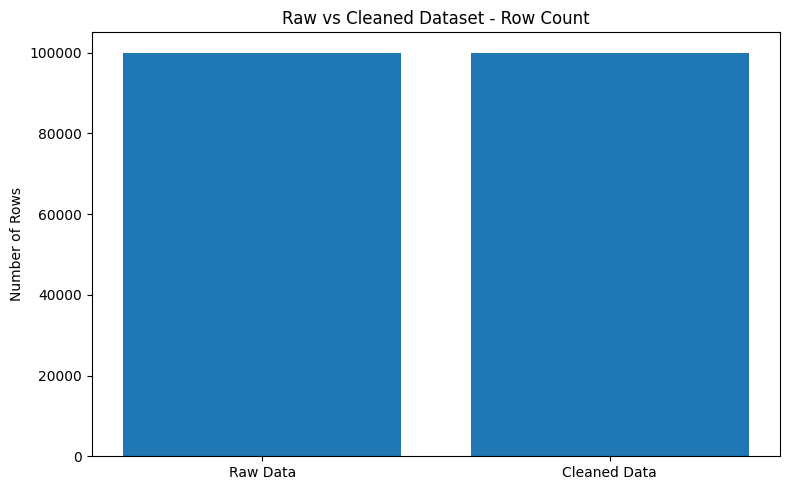

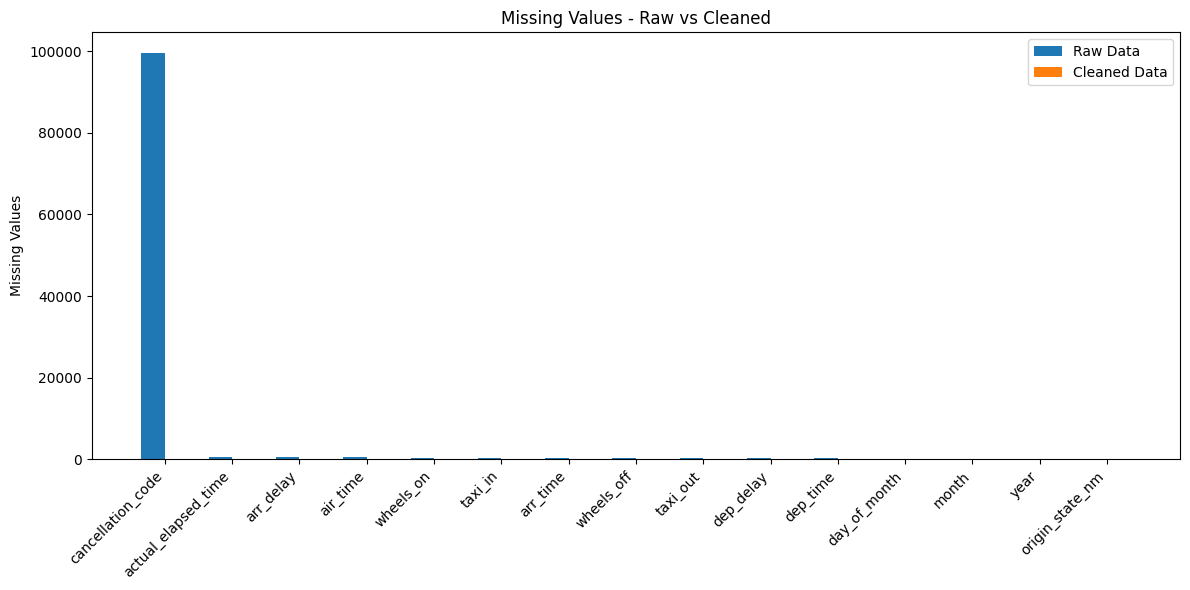

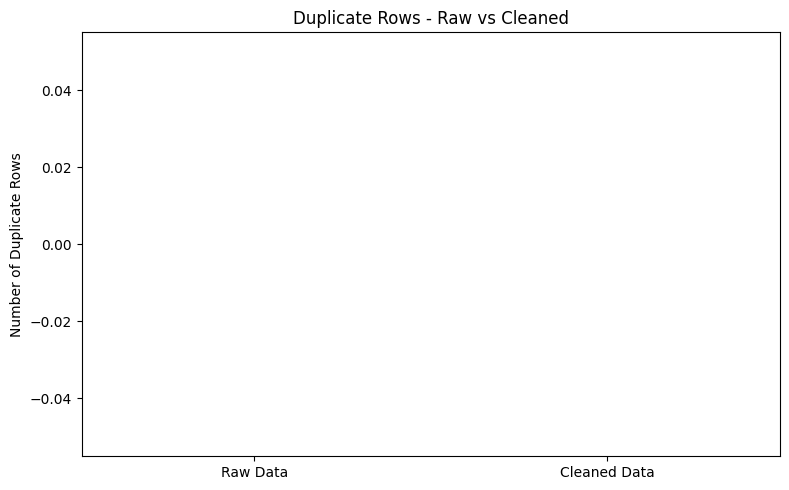


Numerical columns used:
['dep_delay', 'arr_delay', 'distance', 'air_time', 'taxi_out', 'taxi_in', 'actual_elapsed_time', 'crs_elapsed_time']


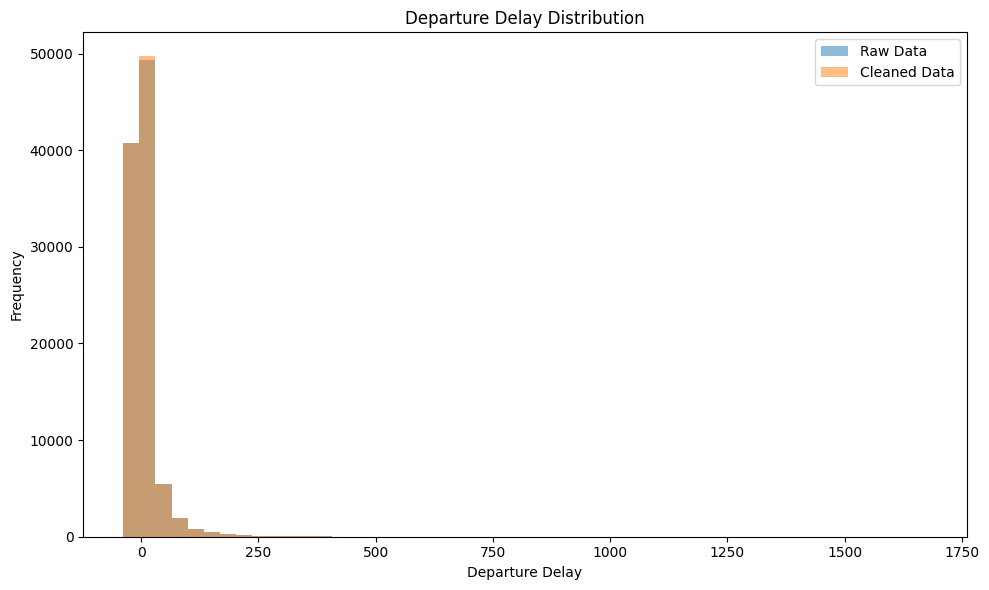

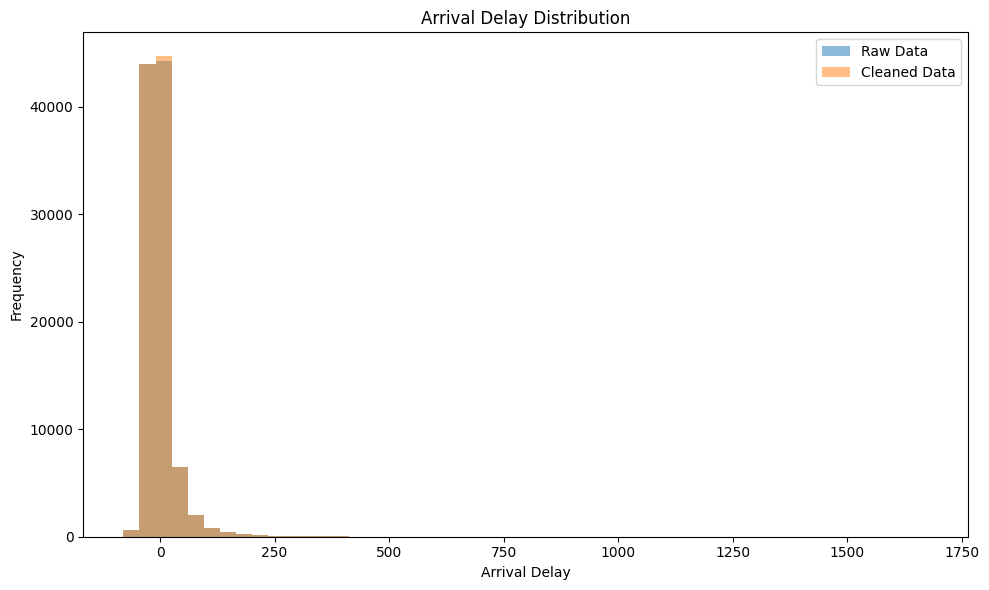

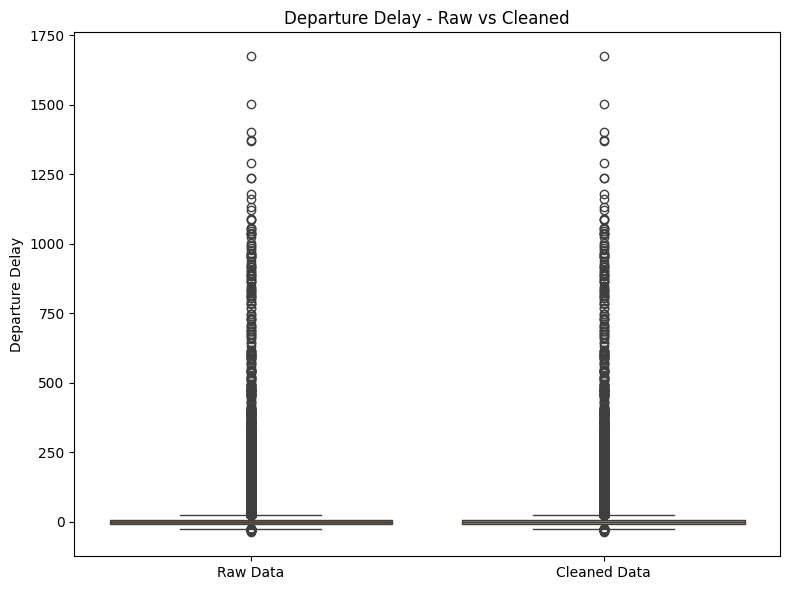

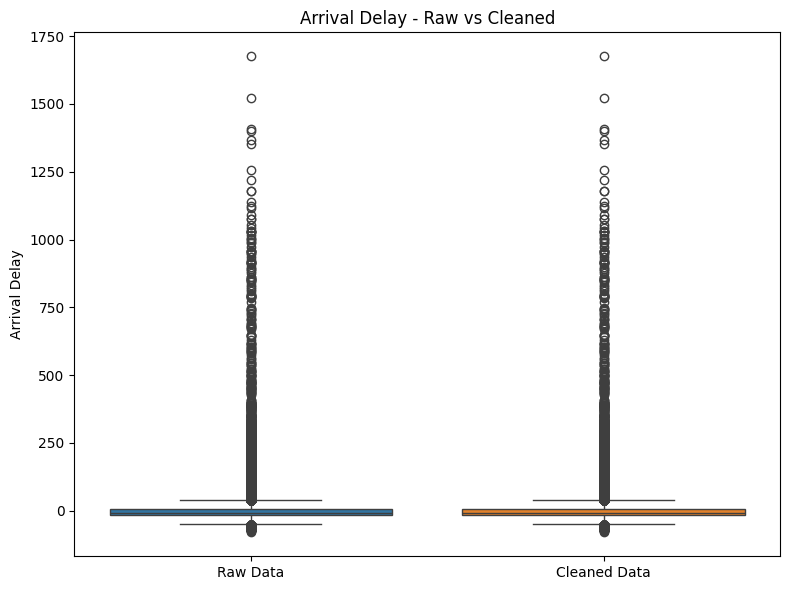

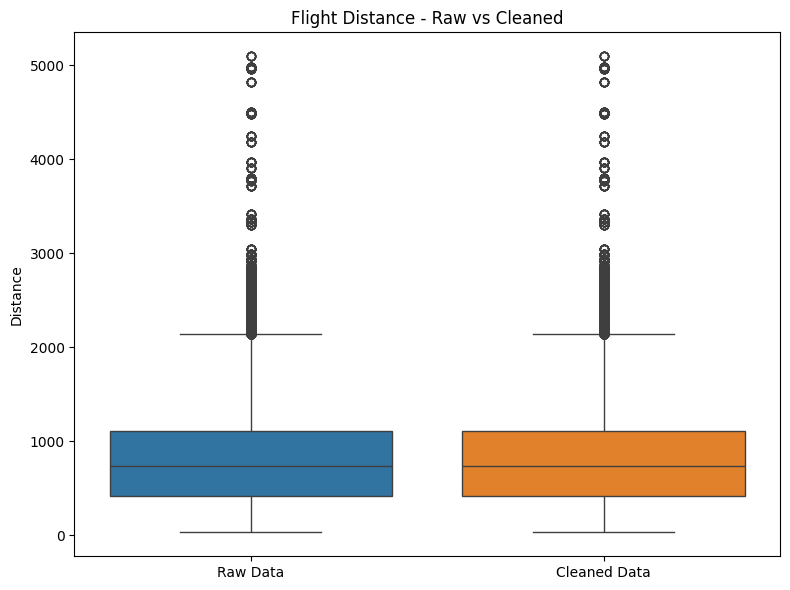

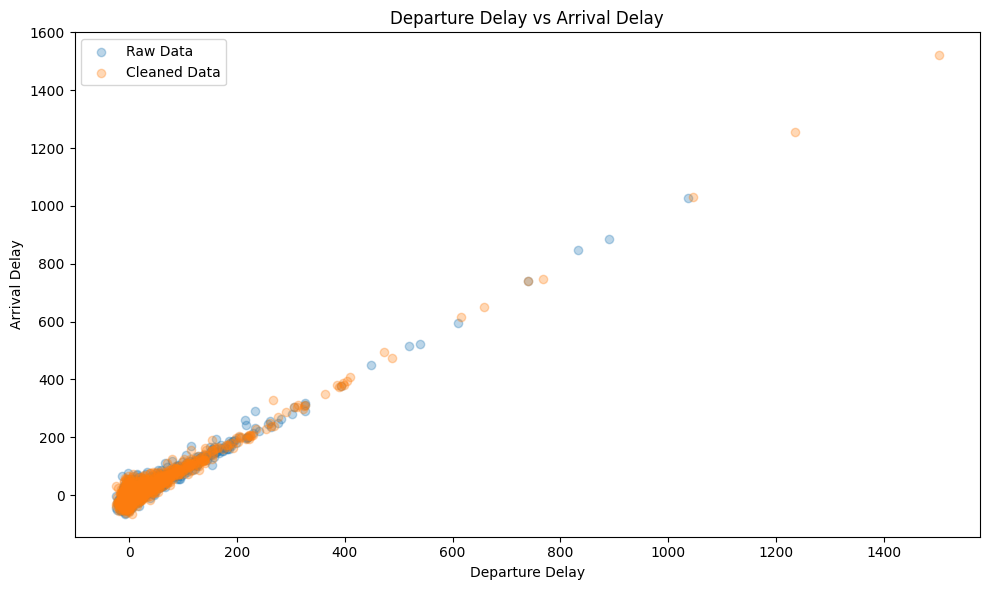

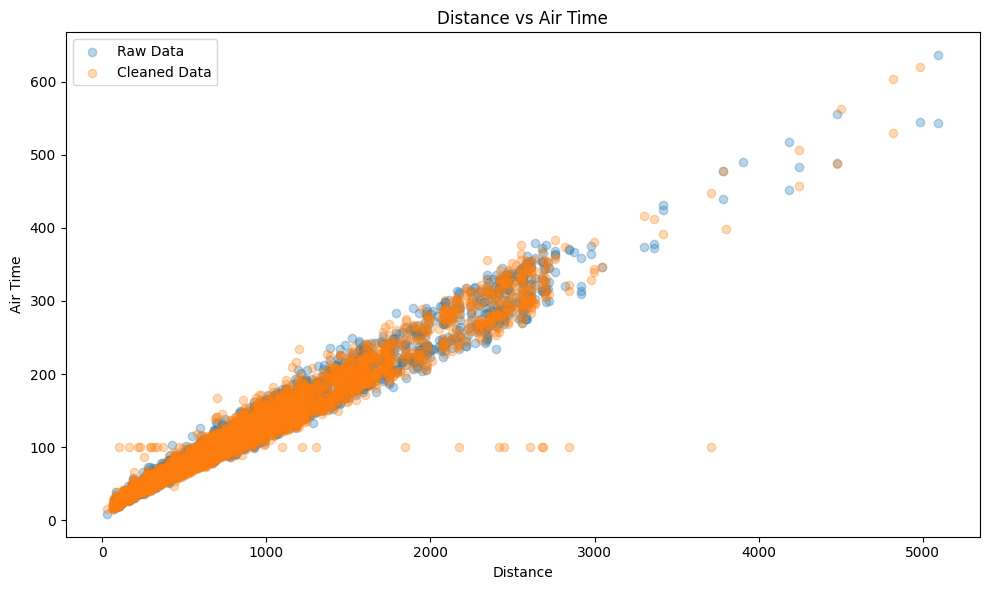

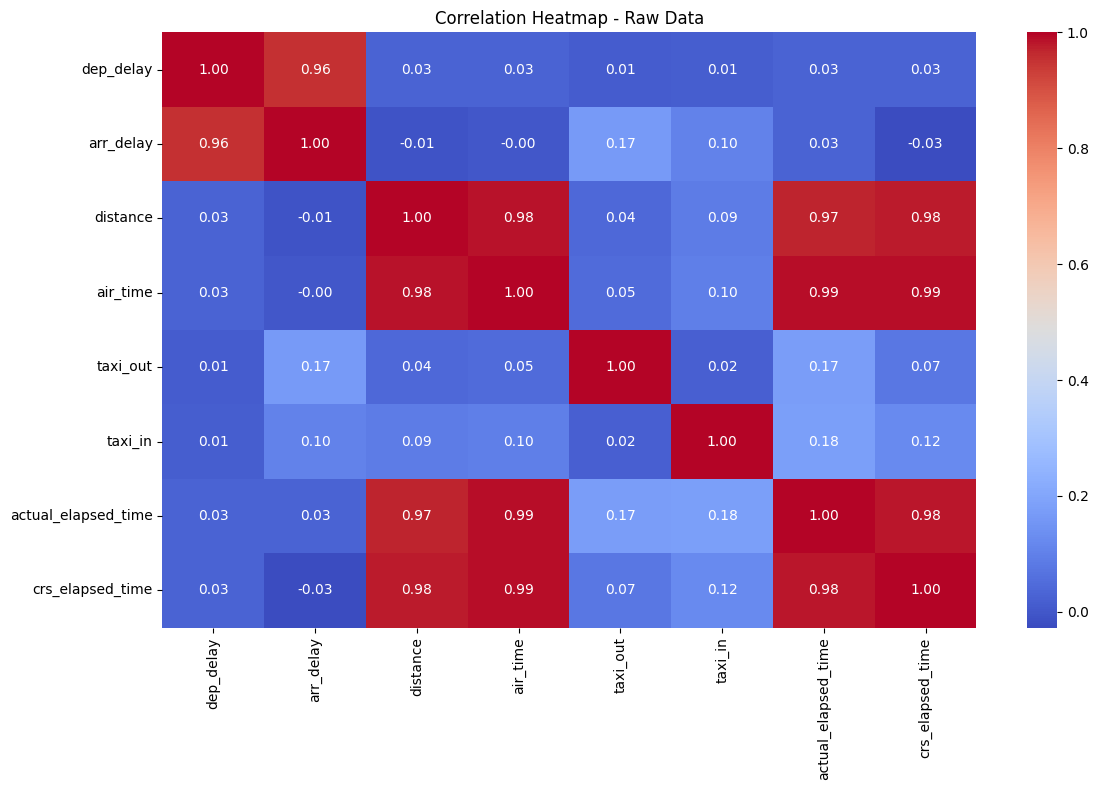

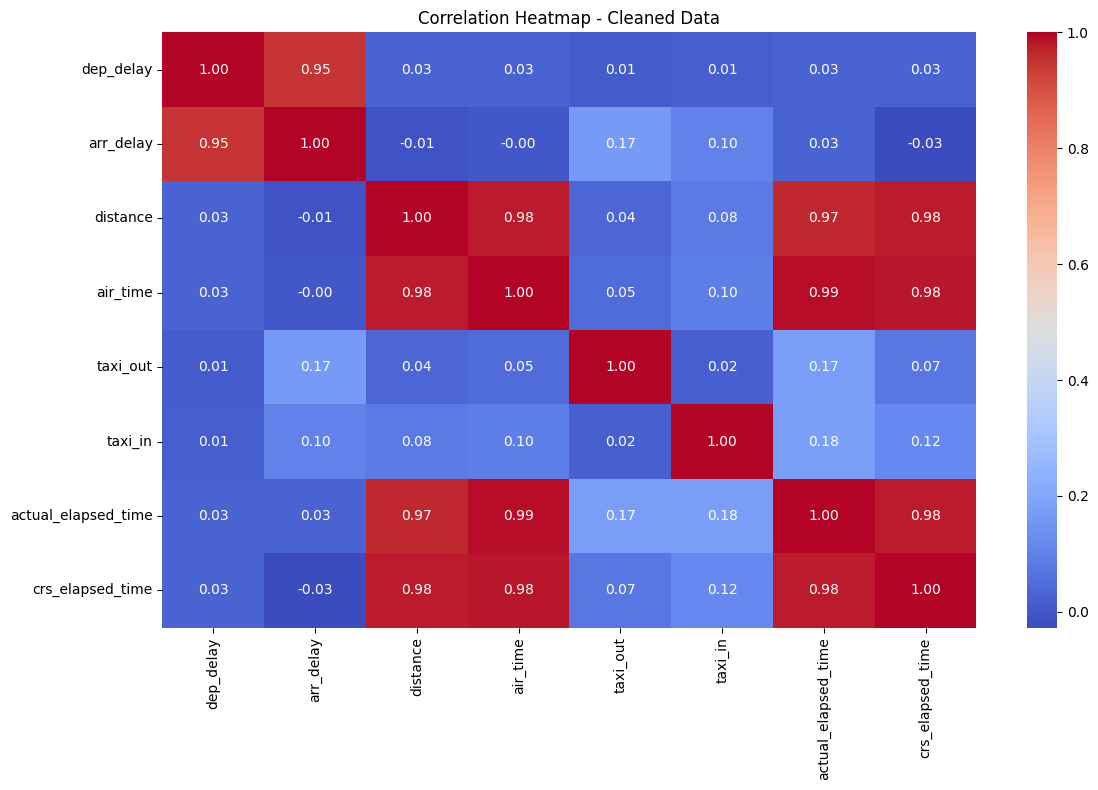

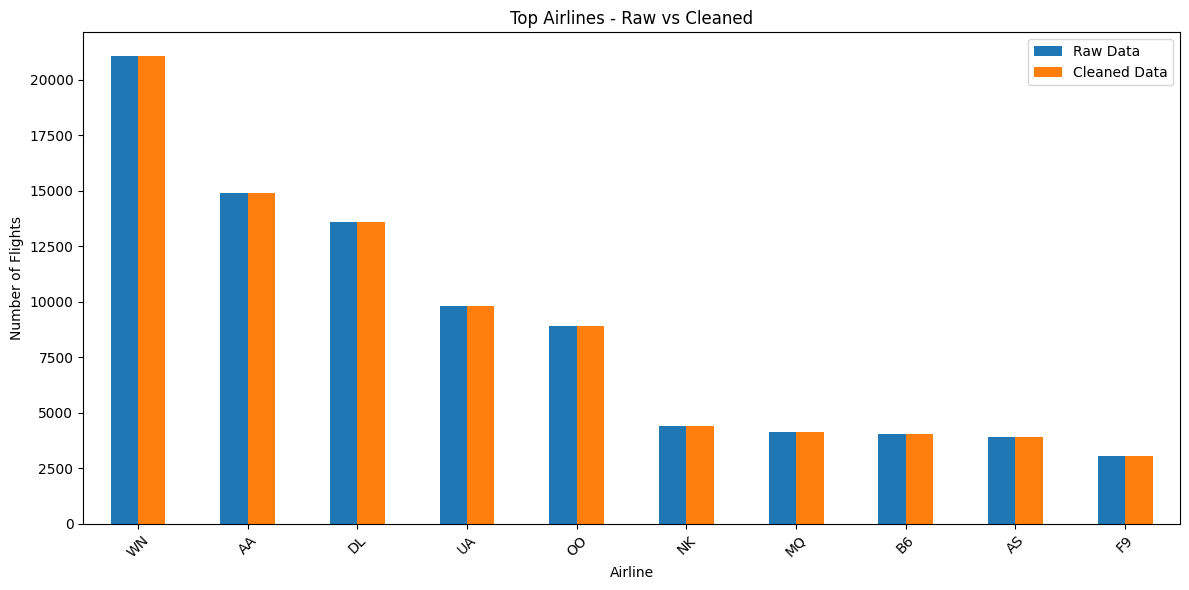

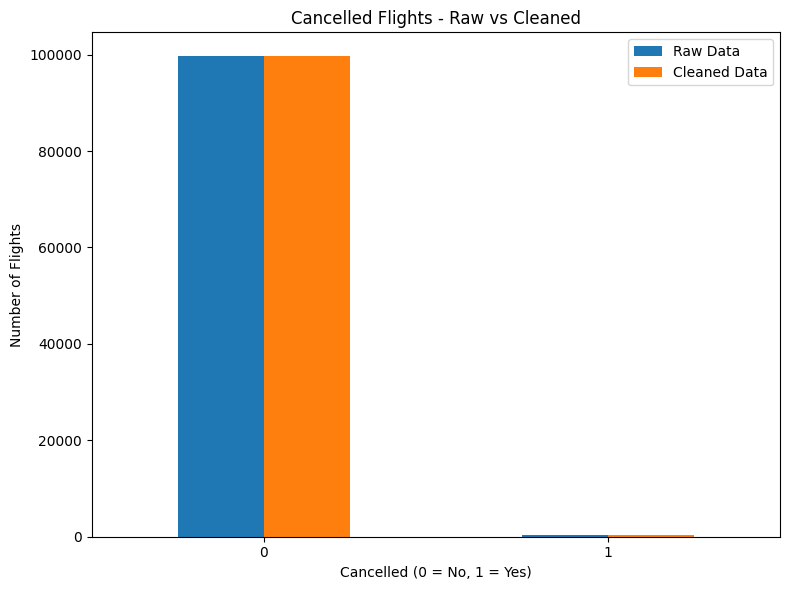


RAW VS CLEANED VISUALIZATION COMPLETED
Raw dataset: /kaggle/input/flight-data-2024/flight_data_2024.csv
Cleaned dataset: /content/flight_data_2024_cleaned.csv
Sample size used for visualization: 100000


In [ ]:
!pip -q install matplotlib seaborn

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# This program compares the raw Kaggle flight dataset with the cleaned dataset using different visualizations.

print("FLIGHT DATA 2024 - RAW VS CLEANED VISUALIZATION")

# This automatically downloads the original flight dataset from Kaggle without requiring manual file upload.
dataset_path = kagglehub.dataset_download(
    "hrishitpatil/flight-data-2024"
)

print("Raw dataset location:", dataset_path)

# This searches the downloaded Kaggle folder and finds all CSV files automatically.
csv_files = glob.glob(
    os.path.join(dataset_path, "**", "*.csv"),
    recursive=True
)

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found inside the Kaggle dataset.")

# This selects the main flight CSV file and ignores sample files.
raw_file = None

for file in csv_files:
    name = os.path.basename(file).lower()

    if "flight_data_2024.csv" in name and "sample" not in name:
        raw_file = file
        break

# This selects the largest CSV file if the expected filename is not found.
if raw_file is None:
    raw_file = max(
        csv_files,
        key=os.path.getsize
    )

print("Raw dataset selected:", raw_file)

# This checks whether the cleaned dataset created by your previous cleaning code exists.
cleaned_file = "/content/flight_data_2024_cleaned.csv"

if not os.path.exists(cleaned_file):
    raise FileNotFoundError(
        "Cleaned dataset not found; run the data cleaning code first."
    )

print("Cleaned dataset found:", cleaned_file)

# This reads only a sample of the raw and cleaned datasets to avoid using too much Colab memory.
SAMPLE_SIZE = 100000

raw_sample = pd.read_csv(
    raw_file,
    nrows=SAMPLE_SIZE,
    low_memory=False
)

cleaned_sample = pd.read_csv(
    cleaned_file,
    nrows=SAMPLE_SIZE,
    low_memory=False
)

print("Raw sample shape:", raw_sample.shape)
print("Cleaned sample shape:", cleaned_sample.shape)

# This standardizes column names so both datasets use the same column naming format.
raw_sample.columns = (
    raw_sample.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

cleaned_sample.columns = (
    cleaned_sample.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# This calculates the number of missing values in each column for both datasets.
raw_missing = raw_sample.isna().sum()
cleaned_missing = cleaned_sample.isna().sum()

missing_comparison = pd.DataFrame({
    "Raw": raw_missing,
    "Cleaned": cleaned_missing
})

missing_comparison["Difference"] = (
    missing_comparison["Raw"]
    - missing_comparison["Cleaned"]
)

missing_comparison = missing_comparison.sort_values(
    "Raw",
    ascending=False
)

print("\nMissing value comparison:")
print(missing_comparison.head(15))

# This counts duplicate rows in the raw and cleaned samples.
raw_duplicates = raw_sample.duplicated().sum()
cleaned_duplicates = cleaned_sample.duplicated().sum()

print("\nRaw duplicate rows:", raw_duplicates)
print("Cleaned duplicate rows:", cleaned_duplicates)

# This plot compares the number of rows in the raw and cleaned samples.
plt.figure(figsize=(8, 5))

plt.bar(
    ["Raw Data", "Cleaned Data"],
    [len(raw_sample), len(cleaned_sample)]
)

plt.title("Raw vs Cleaned Dataset - Row Count")
plt.ylabel("Number of Rows")

plt.tight_layout()
plt.show()

# This plot compares missing values before and after cleaning for the columns with the most missing data.
top_missing = missing_comparison.head(15)

plt.figure(figsize=(12, 6))

x = np.arange(len(top_missing))
width = 0.35

plt.bar(
    x - width / 2,
    top_missing["Raw"],
    width,
    label="Raw Data"
)

plt.bar(
    x + width / 2,
    top_missing["Cleaned"],
    width,
    label="Cleaned Data"
)

plt.xticks(
    x,
    top_missing.index,
    rotation=45,
    ha="right"
)

plt.ylabel("Missing Values")
plt.title("Missing Values - Raw vs Cleaned")
plt.legend()

plt.tight_layout()
plt.show()

# This plot compares duplicate records found in the raw and cleaned samples.
plt.figure(figsize=(8, 5))

plt.bar(
    ["Raw Data", "Cleaned Data"],
    [raw_duplicates, cleaned_duplicates]
)

plt.title("Duplicate Rows - Raw vs Cleaned")
plt.ylabel("Number of Duplicate Rows")

plt.tight_layout()
plt.show()

# This identifies important numerical flight columns that are available in both datasets.
numeric_candidates = [
    "dep_delay",
    "arr_delay",
    "distance",
    "air_time",
    "taxi_out",
    "taxi_in",
    "actual_elapsed_time",
    "crs_elapsed_time"
]

numeric_columns = [
    col for col in numeric_candidates
    if col in raw_sample.columns
    and col in cleaned_sample.columns
]

print("\nNumerical columns used:")
print(numeric_columns)

# This converts the selected flight columns into numerical data for plotting.
for col in numeric_columns:

    raw_sample[col] = pd.to_numeric(
        raw_sample[col],
        errors="coerce"
    )

    cleaned_sample[col] = pd.to_numeric(
        cleaned_sample[col],
        errors="coerce"
    )

# This histogram compares the distribution of departure delays before and after cleaning.
if "dep_delay" in numeric_columns:

    plt.figure(figsize=(10, 6))

    plt.hist(
        raw_sample["dep_delay"].dropna(),
        bins=50,
        alpha=0.5,
        label="Raw Data"
    )

    plt.hist(
        cleaned_sample["dep_delay"].dropna(),
        bins=50,
        alpha=0.5,
        label="Cleaned Data"
    )

    plt.title("Departure Delay Distribution")
    plt.xlabel("Departure Delay")
    plt.ylabel("Frequency")
    plt.legend()

    plt.tight_layout()
    plt.show()

# This histogram compares the distribution of arrival delays before and after cleaning.
if "arr_delay" in numeric_columns:

    plt.figure(figsize=(10, 6))

    plt.hist(
        raw_sample["arr_delay"].dropna(),
        bins=50,
        alpha=0.5,
        label="Raw Data"
    )

    plt.hist(
        cleaned_sample["arr_delay"].dropna(),
        bins=50,
        alpha=0.5,
        label="Cleaned Data"
    )

    plt.title("Arrival Delay Distribution")
    plt.xlabel("Arrival Delay")
    plt.ylabel("Frequency")
    plt.legend()

    plt.tight_layout()
    plt.show()

# This box plot compares departure delay values and helps identify changes and outliers after cleaning.
if "dep_delay" in numeric_columns:

    plot_data = pd.DataFrame({
        "Raw Data": raw_sample["dep_delay"],
        "Cleaned Data": cleaned_sample["dep_delay"]
    })

    plt.figure(figsize=(8, 6))

    sns.boxplot(data=plot_data)

    plt.title("Departure Delay - Raw vs Cleaned")
    plt.ylabel("Departure Delay")

    plt.tight_layout()
    plt.show()

# This box plot compares arrival delay values and helps identify outliers in both datasets.
if "arr_delay" in numeric_columns:

    plot_data = pd.DataFrame({
        "Raw Data": raw_sample["arr_delay"],
        "Cleaned Data": cleaned_sample["arr_delay"]
    })

    plt.figure(figsize=(8, 6))

    sns.boxplot(data=plot_data)

    plt.title("Arrival Delay - Raw vs Cleaned")
    plt.ylabel("Arrival Delay")

    plt.tight_layout()
    plt.show()

# This box plot compares flight distance values between the raw and cleaned datasets.
if "distance" in numeric_columns:

    plot_data = pd.DataFrame({
        "Raw Data": raw_sample["distance"],
        "Cleaned Data": cleaned_sample["distance"]
    })

    plt.figure(figsize=(8, 6))

    sns.boxplot(data=plot_data)

    plt.title("Flight Distance - Raw vs Cleaned")
    plt.ylabel("Distance")

    plt.tight_layout()
    plt.show()

# This scatter plot compares departure delay and arrival delay in the raw and cleaned datasets.
if "dep_delay" in numeric_columns and "arr_delay" in numeric_columns:

    raw_plot = raw_sample[
        ["dep_delay", "arr_delay"]
    ].dropna()

    clean_plot = cleaned_sample[
        ["dep_delay", "arr_delay"]
    ].dropna()

    raw_plot = raw_plot.sample(
        min(5000, len(raw_plot)),
        random_state=42
    )

    clean_plot = clean_plot.sample(
        min(5000, len(clean_plot)),
        random_state=42
    )

    plt.figure(figsize=(10, 6))

    plt.scatter(
        raw_plot["dep_delay"],
        raw_plot["arr_delay"],
        alpha=0.3,
        label="Raw Data"
    )

    plt.scatter(
        clean_plot["dep_delay"],
        clean_plot["arr_delay"],
        alpha=0.3,
        label="Cleaned Data"
    )

    plt.xlabel("Departure Delay")
    plt.ylabel("Arrival Delay")
    plt.title("Departure Delay vs Arrival Delay")
    plt.legend()

    plt.tight_layout()
    plt.show()

# This scatter plot compares flight distance and air time to show whether cleaning affected their relationship.
if "distance" in numeric_columns and "air_time" in numeric_columns:

    raw_plot = raw_sample[
        ["distance", "air_time"]
    ].dropna()

    clean_plot = cleaned_sample[
        ["distance", "air_time"]
    ].dropna()

    raw_plot = raw_plot.sample(
        min(5000, len(raw_plot)),
        random_state=42
    )

    clean_plot = clean_plot.sample(
        min(5000, len(clean_plot)),
        random_state=42
    )

    plt.figure(figsize=(10, 6))

    plt.scatter(
        raw_plot["distance"],
        raw_plot["air_time"],
        alpha=0.3,
        label="Raw Data"
    )

    plt.scatter(
        clean_plot["distance"],
        clean_plot["air_time"],
        alpha=0.3,
        label="Cleaned Data"
    )

    plt.xlabel("Distance")
    plt.ylabel("Air Time")
    plt.title("Distance vs Air Time")
    plt.legend()

    plt.tight_layout()
    plt.show()

# This heatmap shows correlations between numerical variables in the raw dataset.
raw_numeric = raw_sample[
    numeric_columns
].select_dtypes(include="number")

plt.figure(figsize=(12, 8))

sns.heatmap(
    raw_numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Raw Data")

plt.tight_layout()
plt.show()

# This heatmap shows correlations between numerical variables in the cleaned dataset.
clean_numeric = cleaned_sample[
    numeric_columns
].select_dtypes(include="number")

plt.figure(figsize=(12, 8))

sns.heatmap(
    clean_numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Cleaned Data")

plt.tight_layout()
plt.show()

# This chart compares the most common airline codes before and after cleaning.
if "op_unique_carrier" in raw_sample.columns:

    raw_carriers = (
        raw_sample["op_unique_carrier"]
        .astype(str)
        .value_counts()
        .head(10)
    )

    clean_carriers = (
        cleaned_sample["op_unique_carrier"]
        .astype(str)
        .value_counts()
        .head(10)
    )

    carrier_compare = pd.DataFrame({
        "Raw Data": raw_carriers,
        "Cleaned Data": clean_carriers
    }).fillna(0)

    carrier_compare.plot(
        kind="bar",
        figsize=(12, 6)
    )

    plt.title("Top Airlines - Raw vs Cleaned")
    plt.xlabel("Airline")
    plt.ylabel("Number of Flights")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# This chart compares cancelled flights before and after cleaning.
if "cancelled" in raw_sample.columns:

    raw_cancelled = (
        pd.to_numeric(
            raw_sample["cancelled"],
            errors="coerce"
        )
        .value_counts()
        .sort_index()
    )

    clean_cancelled = (
        pd.to_numeric(
            cleaned_sample["cancelled"],
            errors="coerce"
        )
        .value_counts()
        .sort_index()
    )

    cancelled_compare = pd.DataFrame({
        "Raw Data": raw_cancelled,
        "Cleaned Data": clean_cancelled
    }).fillna(0)

    cancelled_compare.plot(
        kind="bar",
        figsize=(8, 6)
    )

    plt.title("Cancelled Flights - Raw vs Cleaned")
    plt.xlabel("Cancelled (0 = No, 1 = Yes)")
    plt.ylabel("Number of Flights")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

# This prints a final message confirming that all raw versus cleaned visualizations have been generated.
print("\n" + "=" * 70)
print("RAW VS CLEANED VISUALIZATION COMPLETED")
print("=" * 70)

print("Raw dataset:", raw_file)
print("Cleaned dataset:", cleaned_file)
print("Sample size used for visualization:", SAMPLE_SIZE)
print("=" * 70)